<a href="https://colab.research.google.com/github/RaulShahi/ML-05-SVR/blob/main/support_vector_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Regression (SVR)

## Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Importing the dataset

In [8]:
dataset = pd.read_csv("Position_Salaries.csv")
X = dataset.iloc[:,1:-1].values
y = dataset.iloc[:,-1].values

In [ ]:
print(X)

In [10]:
#reshaping y to apply feature scaling
y = y.reshape(len(y), 1)

In [ ]:
print(y)

## Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X = sc_X.fit_transform(X)
sc_Y = StandardScaler()
y = sc_Y.fit_transform(y)

In [ ]:
print(X)

In [ ]:
print(y)

## Training the SVR model on the whole dataset

In [15]:
from sklearn.svm import SVR
regressor = SVR(kernel="rbf")
regressor.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

## Predicting a new result

In [18]:
sc_Y.inverse_transform(regressor.predict(sc_X.transform([[6.5]])).reshape(-1,1))

array([[170370.0204065]])

## Visualising the SVR results

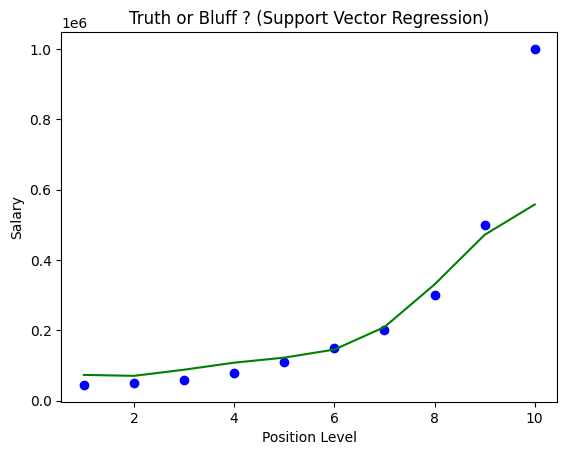

In [21]:
X_og = sc_X.inverse_transform(X)
y_og = sc_Y.inverse_transform(y)
plt.scatter(X_og, y_og, color="blue")
plt.plot(X_og, sc_Y.inverse_transform(regressor.predict(X).reshape(-1,1)), color="green")
plt.title("Truth or Bluff ? (Support Vector Regression)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()